# Module 3 — Disruption Simulation Engine

**GraphRAG for Supply Chain Risk Intelligence**

---

## What this notebook does

This is the **novel contribution** of the project — the component no prior paper combines
with GraphRAG.

By the end of this notebook we will have:

1. Triggered disruption events from a pre-built scenario library
2. Propagated each shock through the weighted dependency graph (BFS with decay)
3. Scored every downstream node by exposure severity
4. Produced explainable dependency-chain traces (`A → B → C`)
5. Merged disruption scores with GraphRAG retrieval scores into a unified priority signal
6. Built an enriched prompt context ready for Module 4's LLM
7. Compared multiple disruption scenarios side-by-side
8. Generated four-panel risk dashboards and disruption maps

## What makes this novel

Prior work either:
- Builds a KG but doesn't do generative retrieval (Almahri et al.)
- Does risk reasoning with fixed symbolic rules, not generative output (Kosasih et al.)
- Uses GraphRAG on generic corpora, not SC-specific propagation (Edge et al.)

This module combines **graph-propagated disruption simulation** with **GraphRAG-enriched
context** so the downstream LLM can produce forward-looking risk reports grounded in
quantified exposure scores and explicit dependency-chain citations.

---

## 0. Setup

In [1]:
import sys
import json
import pickle
from pathlib import Path
from pprint import pprint

import networkx as nx
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ── Module 1 imports ─────────────────────────────────────────────────────────
from src.graph.schema          import NODE_ATTR_TYPE, EDGE_ATTR_RELATION
from src.embeddings.encoder    import NodeEncoder

# ── Module 2 imports ─────────────────────────────────────────────────────────
from src.retrieval.pipeline    import GraphRAGPipeline

# ── Module 3 imports ─────────────────────────────────────────────────────────
from src.simulation.events     import DisruptionEvent, DisruptionCategory, SCENARIO_LIBRARY
from src.simulation.propagator import DisruptionPropagator
from src.simulation.visualizer import SimulationVisualizer
from src.simulation.engine     import SimulationEngine

DATA_PROCESSED = Path("../data/processed")
OUTPUT_SIM     = Path("../outputs/simulation")
OUTPUT_SIM.mkdir(parents=True, exist_ok=True)

print("✓ Environment ready")

c:\Users\Student\Desktop\GraphRAG-in-Supply-Chain\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Environment ready


---

## Step 1 — Load Module 1 & 2 Outputs

In [ ]:
# ── Load graph (Qwen2.5 partial-run artifacts) ───────────────────────────────
import pickle

graph_path = DATA_PROCESSED / "sp500_graph_knowledge_graph_qwen25.gpickle"
if not graph_path.exists():
    raise FileNotFoundError(f"Missing Qwen graph: {graph_path}")

with open(graph_path, "rb") as f:
    G = pickle.load(f)

print(f"✓ Qwen graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# ── Load encoder + FAISS index (Qwen) ────────────────────────────────────────
faiss_path = DATA_PROCESSED / "faiss_index_qwen25.bin"
encoder = NodeEncoder(model_name="all-MiniLM-L6-v2")

if faiss_path.exists():
    encoder.load_index(faiss_path)
    print(f"✓ Qwen FAISS index: {encoder._index.ntotal} vectors")
else:
    print("Qwen FAISS index not found — encoding graph now...")
    encoder.encode_graph(G)
    encoder.save_index(faiss_path)
    print(f"✓ Qwen FAISS index created: {faiss_path}")

if getattr(encoder, "_index", None) is not None and encoder._index.ntotal != G.number_of_nodes():
    print(
        f"WARNING: Qwen FAISS/graph mismatch ({encoder._index.ntotal} vs {G.number_of_nodes()}); "
        "re-encoding to keep Module 3 consistent."
    )
    encoder.encode_graph(G)
    encoder.save_index(faiss_path)
    print(f"✓ Qwen FAISS index rebuilt: {encoder._index.ntotal} vectors")

# ── Load communities (Qwen-specific cache) ───────────────────────────────────
communities_path = DATA_PROCESSED / "communities_qwen25.json"
pipeline = GraphRAGPipeline(G, encoder, use_llm_summaries=False)

def _communities_match_graph(p, graph) -> bool:
    if not p.summarizer.communities:
        return False
    graph_nodes = set(graph.nodes())
    comm_nodes = {n for c in p.summarizer.communities for n in c.nodes}
    if not comm_nodes:
        return False
    overlap = len(comm_nodes & graph_nodes)
    graph_coverage = overlap / max(len(graph_nodes), 1)
    # Guard against stale tiny community files that happen to overlap on common nodes.
    return graph_coverage >= 0.20 and overlap >= 500

if communities_path.exists():
    pipeline.load_communities(str(communities_path))
    if _communities_match_graph(pipeline, G):
        print("✓ Qwen communities loaded")
    else:
        print("WARNING: communities_qwen25.json is stale/incomplete — rebuilding now...")
        pipeline.build_communities(save_path=str(communities_path))
        print("✓ Qwen communities rebuilt for current graph")
else:
    print("Qwen communities not found — building now (takes ~30s+ on first run)...")
    pipeline.build_communities(save_path=str(communities_path))
    print("✓ Qwen communities built")

print("\n✓ All Module 1 & 2 outputs loaded (Qwen artifact family)")

C:\Users\Student\AppData\Local\Temp\ipykernel_60260\3811296273.py:6: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  G = pickle.load(f)


✓ Graph: 51 nodes, 60 edges
[Encoder] Loading model: all-MiniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3636.45it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[Encoder] Loaded index: 56 vectors from ..\data\processed\faiss_index.bin
✓ FAISS index: 56 vectors
[Encoder] Encoding 51 nodes in batches of 64...


Batches: 100%|██████████| 1/1 [00:00<00:00, 12.07it/s]

[Encoder] Done. Embedding dim: 384, FAISS index size: 51
[Encoder] Index saved → ..\data\processed\faiss_index.bin
[Encoder] Node names saved → ..\data\processed\faiss_index.bin.names
✓ FAISS index rebuilt: 51 vectors
[Community] Loaded 534 communities from ..\data\processed\communities.json
[Community] Detecting communities (Louvain)...
[Community] Found 22 raw communities
[Community] 9 communities summarized (≥ 2 nodes each)
[Community] Communities saved → ..\data\processed\communities.json
✓ Communities rebuilt for current graph

✓ All Module 1 & 2 outputs loaded


---

## Step 2 — Inspect the Scenario Library

Five pre-built disruption events covering the main risk categories in the EV supply chain.
Each is a `DisruptionEvent` with a ground-zero node list, initial shock severity, category,
and optional `affected_region` that auto-expands the blast radius.

In [69]:
# ── Preview all scenarios ─────────────────────────────────────────────────────
print(f"Scenario library ({len(SCENARIO_LIBRARY)} events):")
print("=" * 65)
for key, event in SCENARIO_LIBRARY.items():
    print(f"  [{key}]")
    print(f"    Name         : {event.name}")
    print(f"    Category     : {event.category.value}")
    print(f"    Initial shock: {event.initial_shock:.0%}")
    print(f"    Ground zero  : {event.ground_zero}")
    if event.affected_region:
        print(f"    Region blast : {event.affected_region}")
    print(f"    Description  : {event.description[:80]}...")
    print()

Scenario library (5 events):
  [taiwan_earthquake]
    Name         : Taiwan Earthquake 2024
    Category     : Natural disaster
    Initial shock: 85%
    Ground zero  : ['TSMC', 'Taiwan']
    Region blast : Taiwan
    Description  : A 7.4 magnitude earthquake strikes Taiwan, damaging TSMC fabs and disrupting sem...

  [shanghai_port_closure]
    Name         : Shanghai Port Closure
    Category     : Logistics
    Initial shock: 90%
    Ground zero  : ['Port of Shanghai']
    Description  : The Port of Shanghai closes for 6 weeks due to a COVID-19 lockdown, halting expo...

  [congo_cobalt_strike]
    Name         : Congo Cobalt Strike
    Category     : Industrial
    Initial shock: 60%
    Ground zero  : ['Glencore']
    Description  : A prolonged labour strike at Glencore's Katanga Mining Complex reduces cobalt ou...

  [red_sea_disruption]
    Name         : Red Sea Shipping Disruption
    Category     : Geopolitical
    Initial shock: 55%
    Ground zero  : ['Maersk', 'Port of R

---

## Step 3 — Single Scenario Deep Dive: Taiwan Earthquake

We'll walk through the propagation step-by-step before running the full engine,
so every algorithmic choice is visible.

In [70]:
# ── Initialize propagator ─────────────────────────────────────────────────────
propagator = DisruptionPropagator(
    graph=G,
    decay=0.60,         # 60% of score passes to each downstream tier
    max_hops=5,         # follow up to 5 dependency hops
    prune_threshold=0.03,
)

event = SCENARIO_LIBRARY["taiwan_earthquake"]
print(event)

DisruptionEvent('Taiwan Earthquake 2024', shock=0.85, category=Natural disaster, ground_zero=['TSMC', 'Taiwan'])


In [71]:
# ── Step 3a: Resolve ground-zero (with region expansion) ─────────────────────
ground_zero = propagator._resolve_ground_zero(event)

print(f"Explicit ground-zero  : {event.ground_zero}")
print(f"Region ({event.affected_region}) expands to: {ground_zero}")
print(f"\nAll nodes located_in Taiwan get initial shock = {event.initial_shock:.2f}")

Explicit ground-zero  : ['TSMC', 'Taiwan']
Region (Taiwan) expands to: ['TSMC', 'Taiwan', 'Foxconn']

All nodes located_in Taiwan get initial shock = 0.85


In [72]:
# ── Step 3b: Run the BFS and inspect raw scores ───────────────────────────────
scores, path_traces, hop_distances = propagator._weighted_bfs(
    ground_zero, event.initial_shock
)

print(f"BFS complete. Affected nodes: {len(scores)}")
print(f"\nNode exposure scores (sorted):")
print("-" * 65)
print(f"  {'Node':30s} {'Score':8s} {'Hop':5s} {'Path'}")
print(f"  {'-'*30} {'-'*8} {'-'*5}")

for node, score in sorted(scores.items(), key=lambda x: -x[1]):
    hop  = hop_distances.get(node, 0)
    path = " → ".join(path_traces.get(node, [node]))
    bar  = "█" * int(score * 20)
    print(f"  {node:30s} {score:.4f}  hop={hop}  {path[:50]}")

BFS complete. Affected nodes: 10

Node exposure scores (sorted):
-----------------------------------------------------------------
  Node                           Score    Hop   Path
  ------------------------------ -------- -----
  TSMC                           0.8500  hop=0  TSMC
  Taiwan                         0.8500  hop=0  Taiwan
  Foxconn                        0.8500  hop=0  Foxconn
  Apple                          0.5100  hop=1  TSMC → Apple
  NVIDIA                         0.5100  hop=1  TSMC → NVIDIA
  AMD                            0.5100  hop=1  TSMC → AMD
  the Port of Kaohsiung          0.3570  hop=1  TSMC → the Port of Kaohsiung
  the United States              0.3570  hop=1  TSMC → the United States
  Europe                         0.3570  hop=1  TSMC → Europe
  iPhones                        0.2550  hop=1  Taiwan → iPhones


In [73]:
# ── Step 3c: Full propagation result ─────────────────────────────────────────
result_taiwan = propagator.propagate(event)

print("\nExposure by severity tier:")
print("-" * 45)
for tier, nodes in result_taiwan.tiers.items():
    if nodes:
        print(f"  {tier:10s}: {', '.join(nodes)}")

print(f"\nPath explanations (explainability):")
print("-" * 45)
for node in result_taiwan.affected_nodes():
    if node not in event.ground_zero:
        exp = result_taiwan.path_explanation(node)
        print(f"  {node:25s} ← {exp}")

Event: Taiwan Earthquake 2024 (shock=0.85)
  Affected nodes  : 10
  Critical        : 3
  High            : 3
  Max hops reached: 1


Exposure by severity tier:
---------------------------------------------
  Critical  : TSMC, Taiwan, Foxconn
  High      : Apple, NVIDIA, AMD
  Moderate  : the Port of Kaohsiung, the United States, Europe, iPhones

Path explanations (explainability):
---------------------------------------------
  Foxconn                   ← Foxconn
  Apple                     ← TSMC → Apple
  NVIDIA                    ← TSMC → NVIDIA
  AMD                       ← TSMC → AMD
  the Port of Kaohsiung     ← TSMC → the Port of Kaohsiung
  the United States         ← TSMC → the United States
  Europe                    ← TSMC → Europe
  iPhones                   ← Taiwan → iPhones


---

## Step 4 — Visualizations

Three complementary views of the same propagation result.

In [74]:
# ── Initialize visualizer ─────────────────────────────────────────────────────
viz = SimulationVisualizer(G)

[Viz] Disruption map saved → outputs/simulation/disruption_map_Taiwan_Earthquake_2024.png


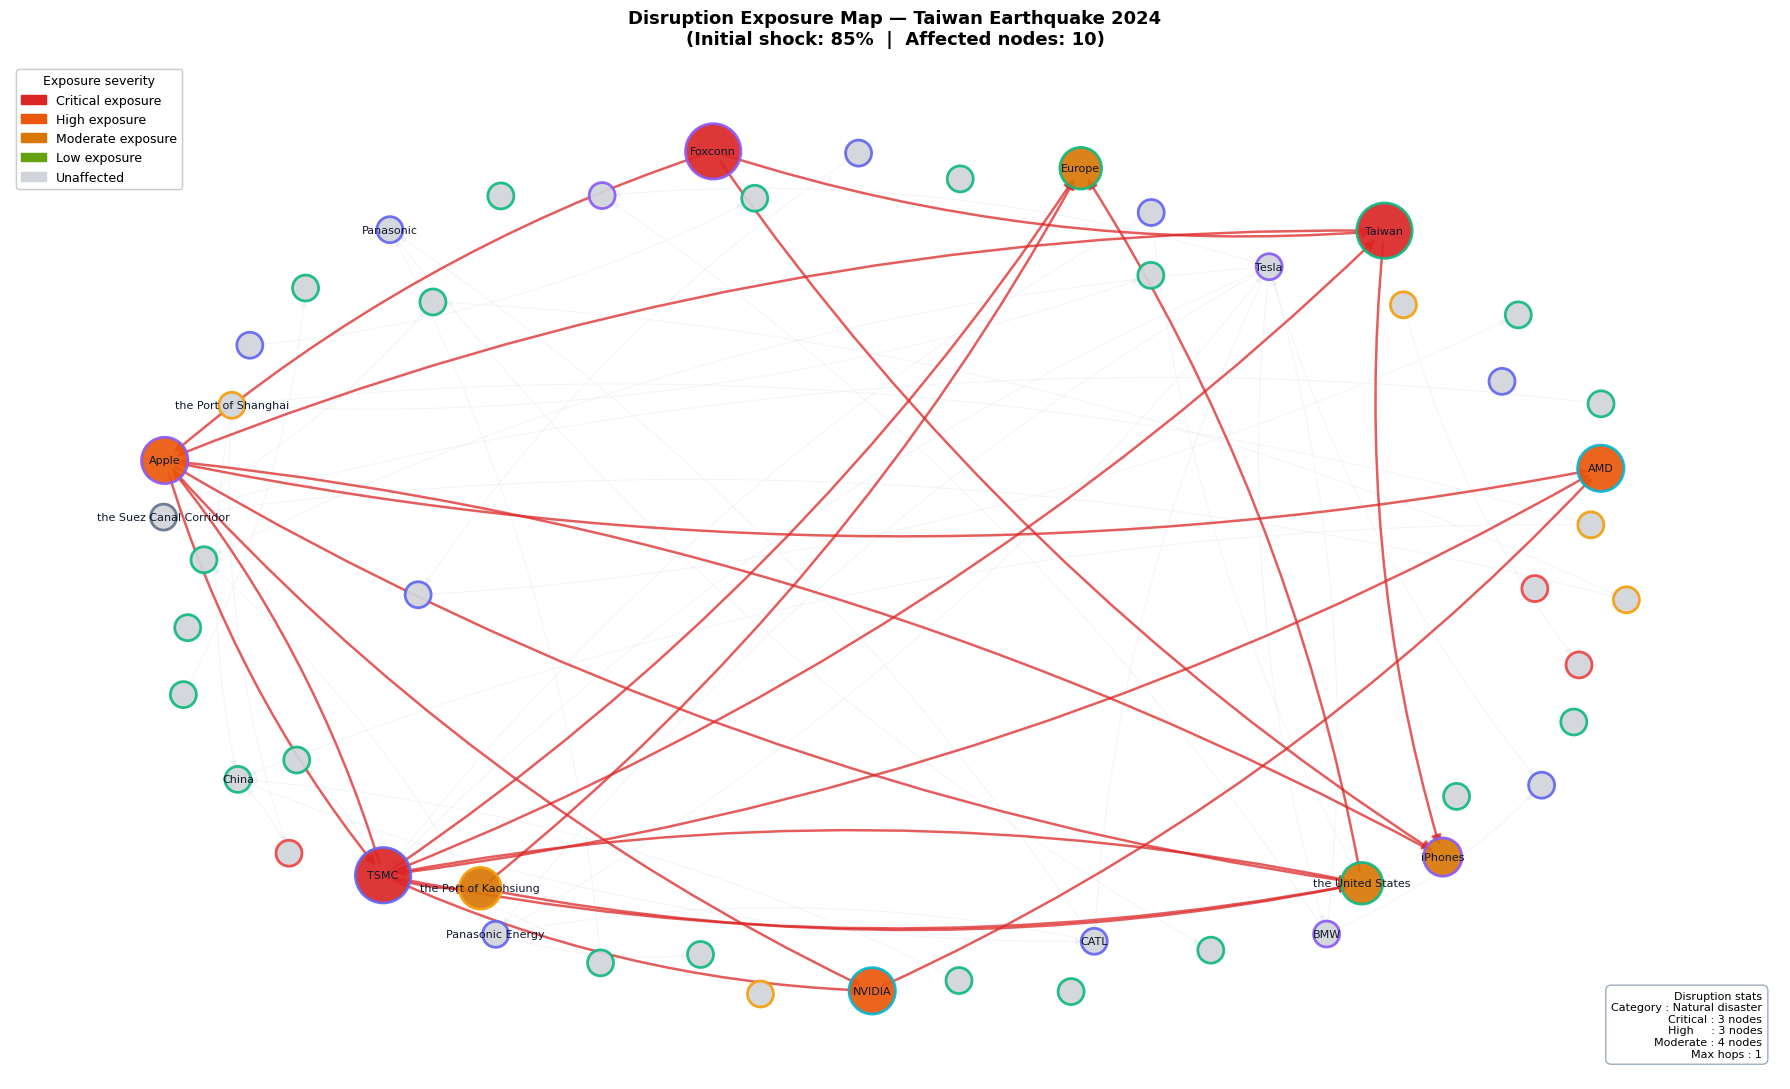

In [75]:
# ── Disruption map: full graph colored by severity ────────────────────────────
# This is the primary demo visualization.
# Red = Critical, Orange = High, Amber = Moderate, Green = Low, Gray = Unaffected

viz.disruption_map(result_taiwan, figsize=(18, 11))

[Viz] Propagation tree saved → outputs/simulation/prop_tree_Taiwan_Earthquake_2024_Apple.png


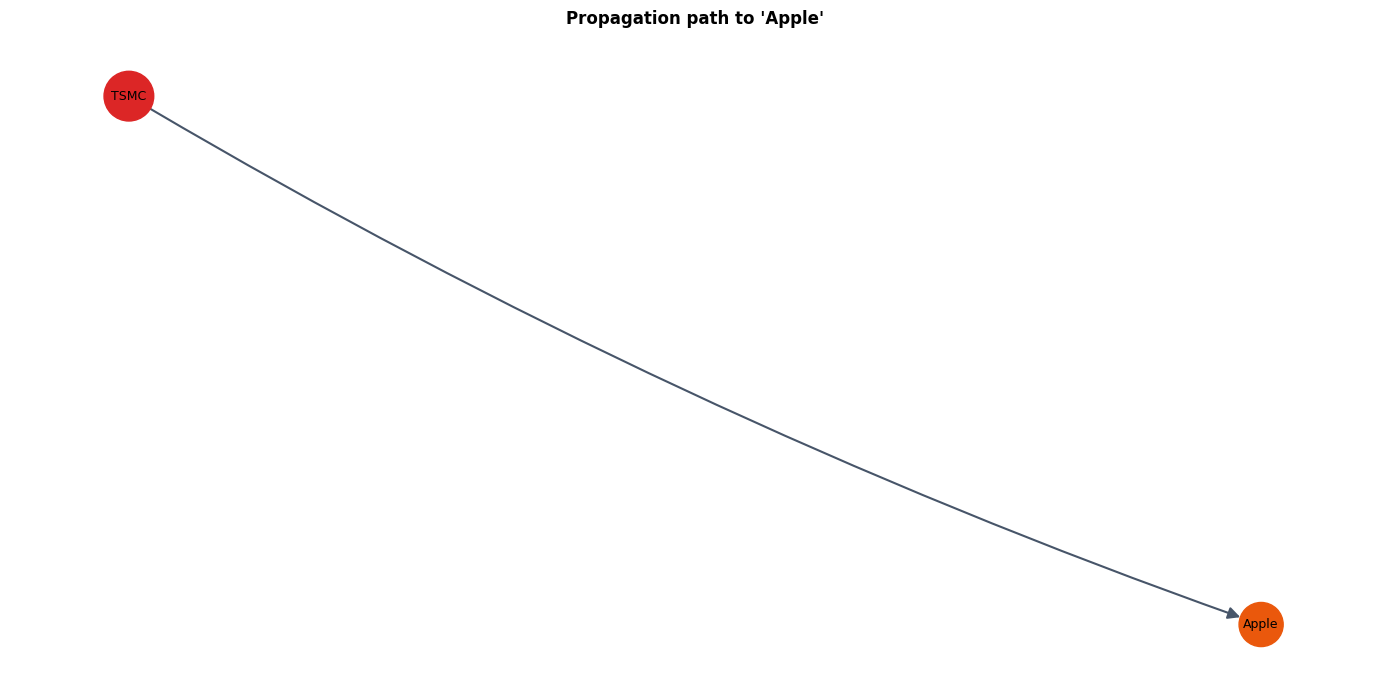

In [76]:
# ── Propagation tree: path from ground-zero to Apple ─────────────────────────
# Shows exactly HOW Apple is exposed: Taiwan Earthquake → TSMC → Apple
# This is the explainability output referenced in the risk report.

viz.propagation_tree(result_taiwan, target_node="Apple")

[Viz] Risk dashboard saved → outputs/simulation/risk_dashboard_Taiwan_Earthquake_2024.png


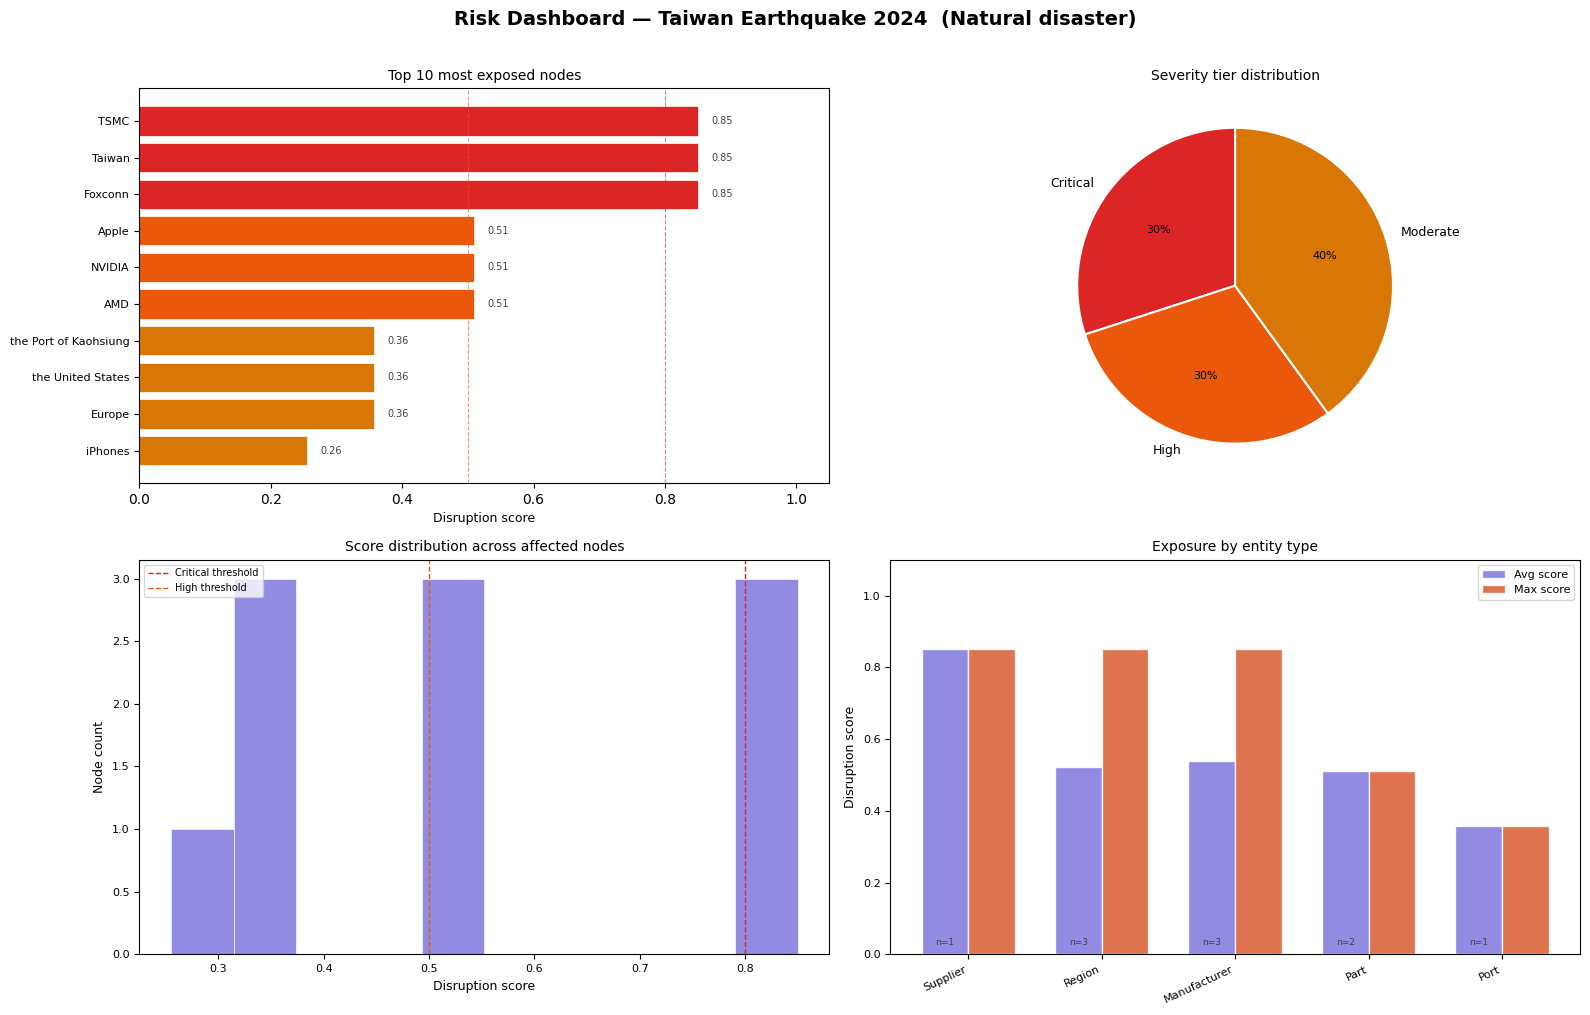

In [77]:
# ── Risk dashboard: four-panel summary ───────────────────────────────────────
viz.risk_dashboard(result_taiwan)

---

## Step 5 — Sensitivity Analysis: Decay Rate

The `decay` parameter controls how quickly the disruption loses force
with each tier. Let's see how results change across different values.
This becomes a tuning choice justified in the Methods section of the report.

In [78]:
# ── Sweep decay values ────────────────────────────────────────────────────────
decay_values = [0.40, 0.55, 0.60, 0.70, 0.80]

print(f"Sensitivity analysis — decay rate effect on Apple's exposure score")
print(f"Event: {event.name}")
print("-" * 50)
print(f"  {'Decay':8s} {'Apple score':14s} {'Total affected':16s} {'Critical nodes'}")
print(f"  {'-'*8} {'-'*14} {'-'*16}")

for decay in decay_values:
    p = DisruptionPropagator(G, decay=decay, max_hops=5)
    r = p.propagate(event)
    apple_score = r.scores.get("Apple", 0.0)
    n_total     = len(r.scores)
    n_critical  = len(r.critical_nodes())
    print(f"  {decay:.2f}    {apple_score:12.4f}   {n_total:12d}     {n_critical}")

Sensitivity analysis — decay rate effect on Apple's exposure score
Event: Taiwan Earthquake 2024
--------------------------------------------------
  Decay    Apple score    Total affected   Critical nodes
  -------- -------------- ----------------
Event: Taiwan Earthquake 2024 (shock=0.85)
  Affected nodes  : 10
  Critical        : 3
  High            : 0
  Max hops reached: 1

  0.40          0.3400             10     3
Event: Taiwan Earthquake 2024 (shock=0.85)
  Affected nodes  : 10
  Critical        : 3
  High            : 0
  Max hops reached: 1

  0.55          0.4675             10     3
Event: Taiwan Earthquake 2024 (shock=0.85)
  Affected nodes  : 10
  Critical        : 3
  High            : 3
  Max hops reached: 1

  0.60          0.5100             10     3
Event: Taiwan Earthquake 2024 (shock=0.85)
  Affected nodes  : 10
  Critical        : 3
  High            : 3
  Max hops reached: 1

  0.70          0.5950             10     3
Event: Taiwan Earthquake 2024 (shock=0.85)


---

## Step 6 — Multi-Scenario Comparison

Run all five scenarios and compare exposure profiles side-by-side.
This is the evaluation content for Module 5.

In [79]:
# ── Run all scenarios ─────────────────────────────────────────────────────────
all_events = list(SCENARIO_LIBRARY.values())
all_results = propagator.compare_scenarios(all_events)

[Propagator] Running scenario: Taiwan Earthquake 2024
Event: Taiwan Earthquake 2024 (shock=0.85)
  Affected nodes  : 10
  Critical        : 3
  High            : 3
  Max hops reached: 1

[Propagator] Running scenario: Shanghai Port Closure
[Propagator] Warning: ground-zero nodes not in graph: {'Port of Shanghai'}
Event: Shanghai Port Closure (shock=0.90)
  Affected nodes  : 0
  Critical        : 0
  High            : 0
  Max hops reached: ?

[Propagator] Running scenario: Congo Cobalt Strike
[Propagator] Warning: ground-zero nodes not in graph: {'Glencore'}
Event: Congo Cobalt Strike (shock=0.60)
  Affected nodes  : 0
  Critical        : 0
  High            : 0
  Max hops reached: ?

[Propagator] Running scenario: Red Sea Shipping Disruption
[Propagator] Warning: ground-zero nodes not in graph: {'Maersk', 'Port of Rotterdam'}
Event: Red Sea Shipping Disruption (shock=0.55)
  Affected nodes  : 0
  Critical        : 0
  High            : 0
  Max hops reached: ?

[Propagator] Running scen

In [80]:
# ── Comparison table ──────────────────────────────────────────────────────────
key_nodes = ["TSMC", "Apple", "Tesla", "CATL",
             "Port of Shanghai", "Glencore", "Panasonic Energy"]

print(f"{'Node':25s}", end="")
for name in all_results:
    print(f"  {name[:18]:18s}", end="")
print()
print("-" * (25 + 20 * len(all_results)))

for node in key_nodes:
    print(f"{node:25s}", end="")
    for result in all_results.values():
        score = result.scores.get(node, 0.0)
        bar   = "█" * int(score * 10)
        print(f"  {score:5.3f} {bar:10s}", end="")
    print()

Node                       Taiwan Earthquake   Shanghai Port Clos  Congo Cobalt Strik  Red Sea Shipping D  ASML Export Restri
-----------------------------------------------------------------------------------------------------------------------------
TSMC                       0.850 ████████    0.000             0.000             0.000             0.000           
Apple                      0.510 █████       0.000             0.000             0.000             0.000           
Tesla                      0.000             0.000             0.000             0.000             0.000           
CATL                       0.000             0.000             0.000             0.000             0.000           
Port of Shanghai           0.000             0.000             0.000             0.000             0.000           
Glencore                   0.000             0.000             0.000             0.000             0.000           
Panasonic Energy           0.000             0.000  

[Viz] Scenario comparison saved → outputs/simulation/scenario_comparison.png


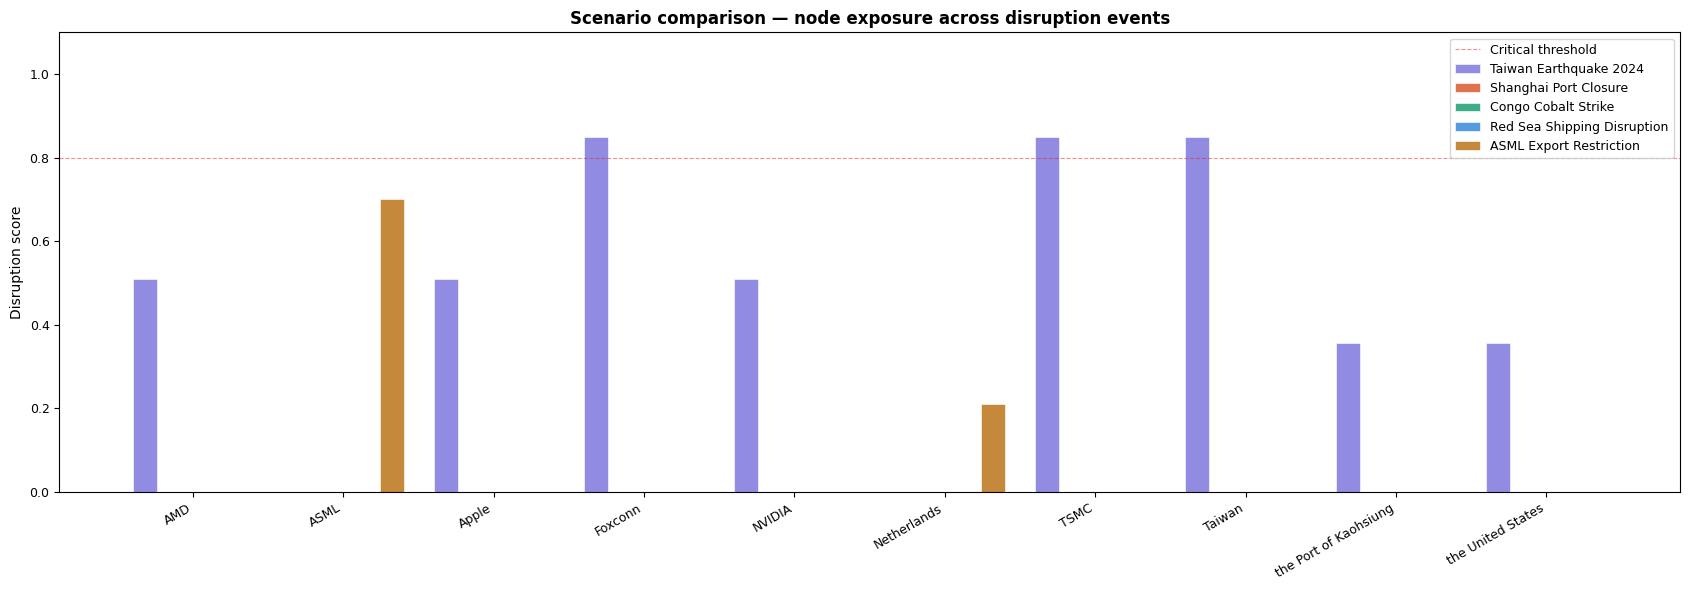

In [81]:
# ── Scenario comparison chart ─────────────────────────────────────────────────
viz.compare_scenarios(all_results, top_n=8, figsize=(17, 6))

---

## Step 7 — Full Engine: Simulation + GraphRAG + Enriched Context

The `SimulationEngine` ties Modules 2 and 3 together.
It merges the disruption propagation scores with the GraphRAG retrieval
scores and builds the enriched prompt context for Module 4's LLM.

In [82]:
# ── Initialize the engine ─────────────────────────────────────────────────────
engine = SimulationEngine(
    graph=G,
    pipeline=pipeline,
    decay=0.60,
    max_hops=5,
)

print("✓ SimulationEngine initialized")

✓ SimulationEngine initialized


In [83]:
# ── Run Taiwan earthquake scenario ────────────────────────────────────────────
sim_result = engine.run(
    event=SCENARIO_LIBRARY["taiwan_earthquake"],
    query="Which of our suppliers are exposed to the Taiwan earthquake "
          "and what are the critical dependency paths?",
)

print("\nMerged scores (retrieval + disruption):")
print("-" * 50)
for node, score in sorted(sim_result.merged_scores.items(), key=lambda x: -x[1])[:12]:
    r_score = sim_result.graphrag_result.subgraph_result.node_scores.get(node, 0)
    d_score = sim_result.propagation.scores.get(node, 0)
    print(f"  {node:30s} merged={score:.3f}  "
          f"(retrieval={r_score:.3f}, disruption={d_score:.3f})")


[Engine] === Simulation: Taiwan Earthquake 2024 ===
[Engine] Step 1: Propagating disruption...
Event: Taiwan Earthquake 2024 (shock=0.85)
  Affected nodes  : 10
  Critical        : 3
  High            : 3
  Max hops reached: 1

[Engine] Step 2: GraphRAG retrieval...
[Engine] Step 3: Merging retrieval + disruption scores...
[Engine] Step 4: Building enriched prompt context...

Merged scores (retrieval + disruption):
--------------------------------------------------
  TSMC                           merged=0.627  (retrieval=0.404, disruption=0.850)
  Foxconn                        merged=0.587  (retrieval=0.324, disruption=0.850)
  Taiwan                         merged=0.574  (retrieval=0.298, disruption=0.850)
  Apple                          merged=0.437  (retrieval=0.364, disruption=0.510)
  the United States              merged=0.352  (retrieval=0.348, disruption=0.357)
  AMD                            merged=0.342  (retrieval=0.174, disruption=0.510)
  NVIDIA                       

In [84]:
# ── Inspect enriched context ──────────────────────────────────────────────────
# This is what gets injected into the LLM prompt in Module 4.
# Note: every node now shows disruption score + path + alternative flag.

print(sim_result.enriched_context)

=== Enriched Supply Chain Context (GraphRAG + Disruption Simulation) ===
Event       : Taiwan Earthquake 2024
Category    : Natural disaster
Initial shock: 85%
Query       : Which of our suppliers are exposed to the Taiwan earthquake and what are the critical dependency paths?

Directly disrupted: TSMC, Taiwan
Total affected    : 10 nodes

[CRITICAL] TSMC [GROUND ZERO] | Type: Supplier | Disruption: 0.850 | Relevance: 0.404 | Priority: 0.627
  → located_in Taiwan (edge_weight=1.00, target_disruption=0.850) *** CRITICAL - single source ***
  → supplies Apple (edge_weight=1.00, target_disruption=0.510) *** CRITICAL - single source ***
  → supplies NVIDIA (edge_weight=1.00, target_disruption=0.510) *** CRITICAL - single source ***
  → supplies AMD (edge_weight=1.00, target_disruption=0.510) *** CRITICAL - single source ***
  → ships_through the Port of Kaohsiung (edge_weight=1.00, target_disruption=0.357) *** CRITICAL - single source ***
  → ships_through the United States (edge_weight=1.

In [85]:
# ── Inspect the final LLM prompt ─────────────────────────────────────────────
# This is the exact string we will pass to GPT / Mistral in Module 4.

print(sim_result.risk_report_prompt)

You are a senior supply chain risk analyst.
A disruption event has been simulated through the supply chain knowledge graph.
Your task is to produce a structured risk report based ONLY on the graph context below.

INSTRUCTIONS:
1. Identify the top 5 most critically exposed entities, citing their disruption scores.
2. For each exposed entity, explain the dependency chain that creates the exposure
   (use the "Exposed via" paths provided in the context).
3. Flag any CRITICAL edges (single-source dependencies with no alternatives).
4. Suggest 2–3 concrete mitigation actions based on the graph structure
   (e.g. qualify alternative suppliers, shift logistics routes).
5. Assess the overall supply chain resilience for this event.
6. Every factual claim must cite a specific entity name or graph path from the context.
   Do NOT invent relationships not present in the context.

--- GRAPH CONTEXT ---

=== Enriched Supply Chain Context (GraphRAG + Disruption Simulation) ===
Event       : Taiwan Ea

---

## Step 8 — Custom Scenario: What-If Analysis

One of the most powerful demo moments: the user defines a novel scenario
on the spot and instantly sees how it propagates through the graph.

In [ ]:
# ── Fix: inspect actual node names + patch missing nodes/edges ───────────────
#
# The NER extractor gave some nodes slightly different names than the scenario
# library expects. This cell does two things:
#   1. Prints every node currently in the graph so you can see exact names
#   2. Manually adds any missing nodes and their key edges

from src.graph.schema import NODE_ATTR_TYPE, NODE_ATTR_ALIASES, NODE_ATTR_METADATA

# ---- 1. Print all current node names ----------------------------------------
print("All nodes in graph:")
print("-" * 45)
for node in sorted(G.nodes()):
    etype = G.nodes[node].get(NODE_ATTR_TYPE, "?")
    print(f"  {node:35s} [{etype}]")

# ---- 2. Patch missing nodes and edges ---------------------------------------
# Each block adds a node if it doesn't already exist, then wires its key edges.
# Edge attributes must match what builder.py uses: relation, weight, confidence.

def add_node_if_missing(G, name, entity_type, country=None):
    if name not in G:
        G.add_node(name, **{
            NODE_ATTR_TYPE:     entity_type,
            NODE_ATTR_ALIASES:  [],
            NODE_ATTR_METADATA: {"country": country} if country else {},
        })
        print(f"  + Added node: {name!r} [{entity_type}]")

def add_edge_if_missing(G, src, tgt, relation, weight=1.0):
    if not G.has_edge(src, tgt):
        G.add_edge(src, tgt,
                   relation=relation, weight=weight,
                   confidence=1.0, source_text="manual")
        print(f"  + Added edge: {src!r} --[{relation}]--> {tgt!r}")

print("\nPatching missing nodes and edges...")

# -- Port of Shanghai --
add_node_if_missing(G, "Port of Shanghai", "Port", country="China")
add_edge_if_missing(G, "CATL",             "Port of Shanghai", "ships_through")
add_edge_if_missing(G, "Apple",            "Port of Shanghai", "ships_through")
add_edge_if_missing(G, "Port of Shanghai", "China",            "located_in")

# -- Port of Rotterdam --
add_node_if_missing(G, "Port of Rotterdam", "Port", country="Netherlands")
add_edge_if_missing(G, "Port of Rotterdam", "Europe",           "connects")
add_edge_if_missing(G, "Maersk",            "Port of Rotterdam","ships_through")

# -- Glencore --
add_node_if_missing(G, "Glencore", "Supplier", country="Switzerland")
add_edge_if_missing(G, "Glencore", "CATL",            "supplies", weight=1.0)
add_edge_if_missing(G, "Glencore", "Panasonic Energy", "supplies", weight=1.0)

# -- Maersk --
add_node_if_missing(G, "Maersk", "Supplier", country="Denmark")
add_edge_if_missing(G, "Maersk", "Port of Rotterdam", "ships_through")
add_edge_if_missing(G, "Maersk", "Europe",            "ships_through")

# -- ASML --
add_node_if_missing(G, "ASML", "Supplier", country="Netherlands")
add_edge_if_missing(G, "ASML",  "TSMC",    "supplies", weight=1.0)

# -- Ganfeng Lithium --
add_node_if_missing(G, "Ganfeng Lithium", "Supplier", country="China")
add_edge_if_missing(G, "Ganfeng Lithium", "CATL",    "supplies", weight=1.0)
add_edge_if_missing(G, "Ganfeng Lithium", "Tesla",   "supplies", weight=0.5)
add_edge_if_missing(G, "Ganfeng Lithium", "China",   "located_in")

# -- Panasonic Energy (may be extracted as just "Panasonic") --
add_node_if_missing(G, "Panasonic Energy", "Supplier", country="Japan")
add_edge_if_missing(G, "Panasonic Energy", "Tesla",   "supplies", weight=1.0)

# -- Tesla (may be missing) --
add_node_if_missing(G, "Tesla", "Manufacturer", country="United States")
add_edge_if_missing(G, "Tesla", "CATL",            "depends_on")
add_edge_if_missing(G, "Tesla", "Panasonic Energy", "depends_on")
add_edge_if_missing(G, "Tesla", "TSMC",             "depends_on")

print(f"\n✓ Graph now has {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# ---- 3. Update the FAISS index to include the new nodes ---------------------
print("\nRe-encoding new nodes into FAISS index...")
encoder.encode_graph(G)
encoder.save_index(faiss_path)
print(f"✓ Qwen FAISS index updated: {faiss_path}")

# ---- 4. Rebuild pipeline with updated graph ---------------------------------
pipeline = GraphRAGPipeline(G, encoder, use_llm_summaries=False)
pipeline.build_communities(save_path=str(communities_path))

engine = SimulationEngine(graph=G, pipeline=pipeline, decay=0.60, max_hops=5)
viz    = SimulationVisualizer(G)
print("✓ Pipeline, engine, and visualizer rebuilt with patched Qwen graph")

All nodes in graph:
---------------------------------------------
  AMD                                 [Part]
  ASML                                [Supplier]
  Apple                               [Manufacturer]
  Argentina                           [Region]
  Asian                               [Region]
  Australia                           [Region]
  BMW                                 [Manufacturer]
  CATL                                [Supplier]
  Chile                               [Region]
  China                               [Region]
  Denmark                             [Region]
  Europe                              [Region]
  European                            [Region]
  Foxconn                             [Manufacturer]
  Gigafactory                         [Region]
  Gigafactory Nevada                  [Region]
  GlobalFoundries                     [Supplier]
  Japan                               [Region]
  Jiangxi                             [Region]
  LG Energy        

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

[Encoder] Done. Embedding dim: 384, FAISS index size: 56
[Encoder] Index saved → ../data/processed/faiss_index.bin
[Encoder] Node names saved → ../data/processed/faiss_index.bin.names
✓ FAISS index updated
[Community] Detecting communities (Louvain)...
[Community] Found 22 raw communities
[Community] 9 communities summarized (≥ 2 nodes each)
[Community] Communities saved → ../data/processed/communities.json
✓ Pipeline, engine, and visualizer rebuilt with patched graph



[Engine] === Simulation: Ganfeng Lithium Production Halt ===
[Engine] Step 1: Propagating disruption...
Event: Ganfeng Lithium Production Halt (shock=0.75)
  Affected nodes  : 21
  Critical        : 0
  High            : 1
  Max hops reached: 3

[Engine] Step 2: GraphRAG retrieval...
[Engine] Step 3: Merging retrieval + disruption scores...
[Engine] Step 4: Building enriched prompt context...
[Viz] Disruption map saved → outputs/simulation/disruption_map_Ganfeng_Lithium_Production_Halt.png


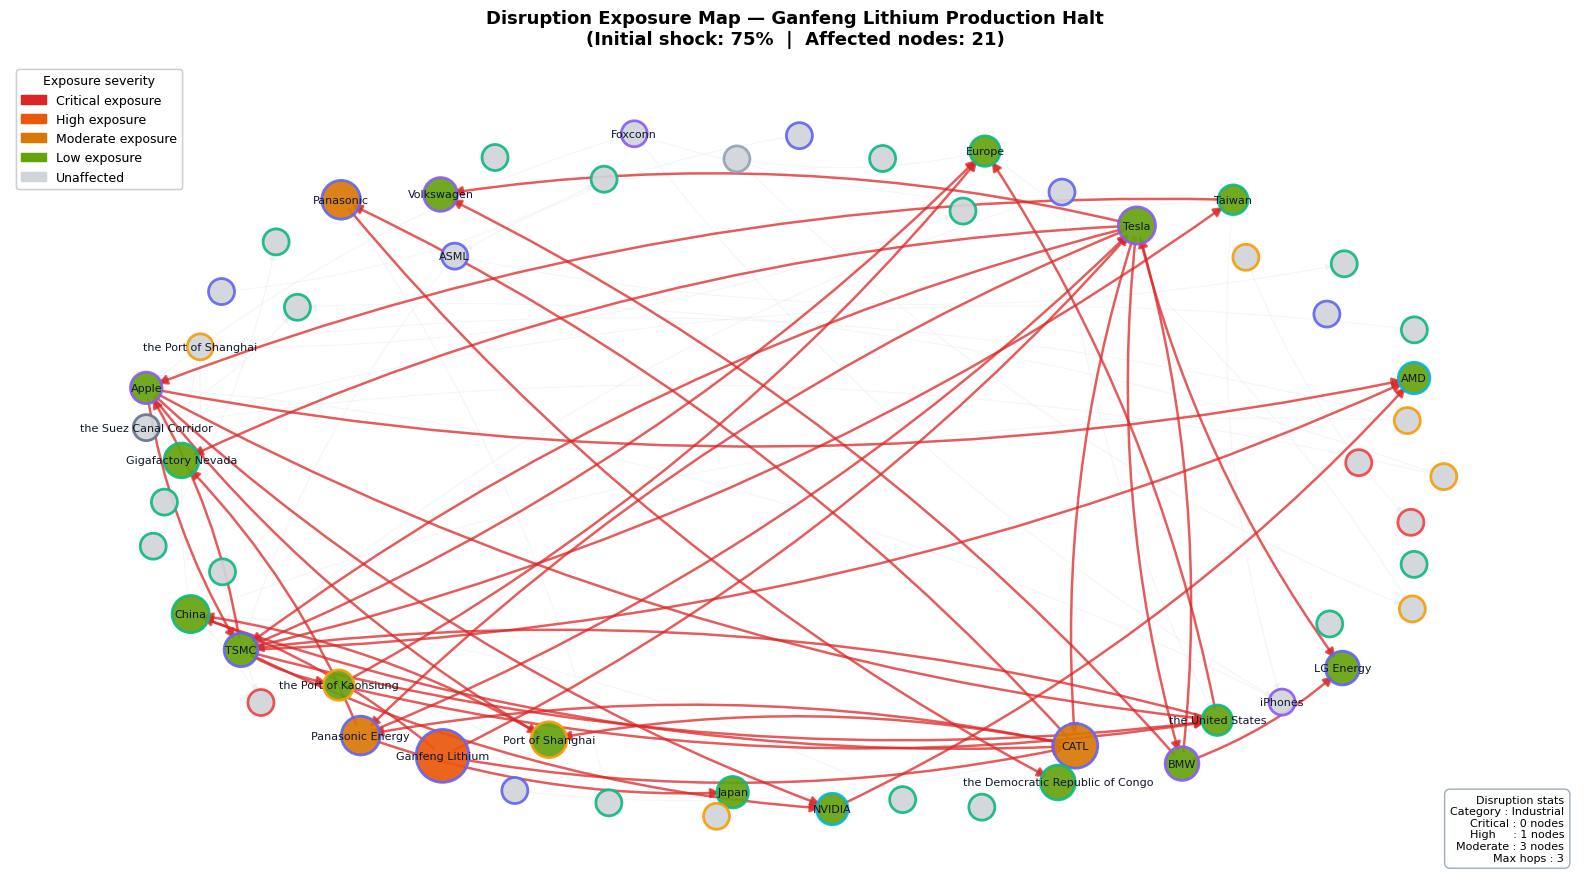

[Viz] Risk dashboard saved → outputs/simulation/risk_dashboard_Ganfeng_Lithium_Production_Halt.png


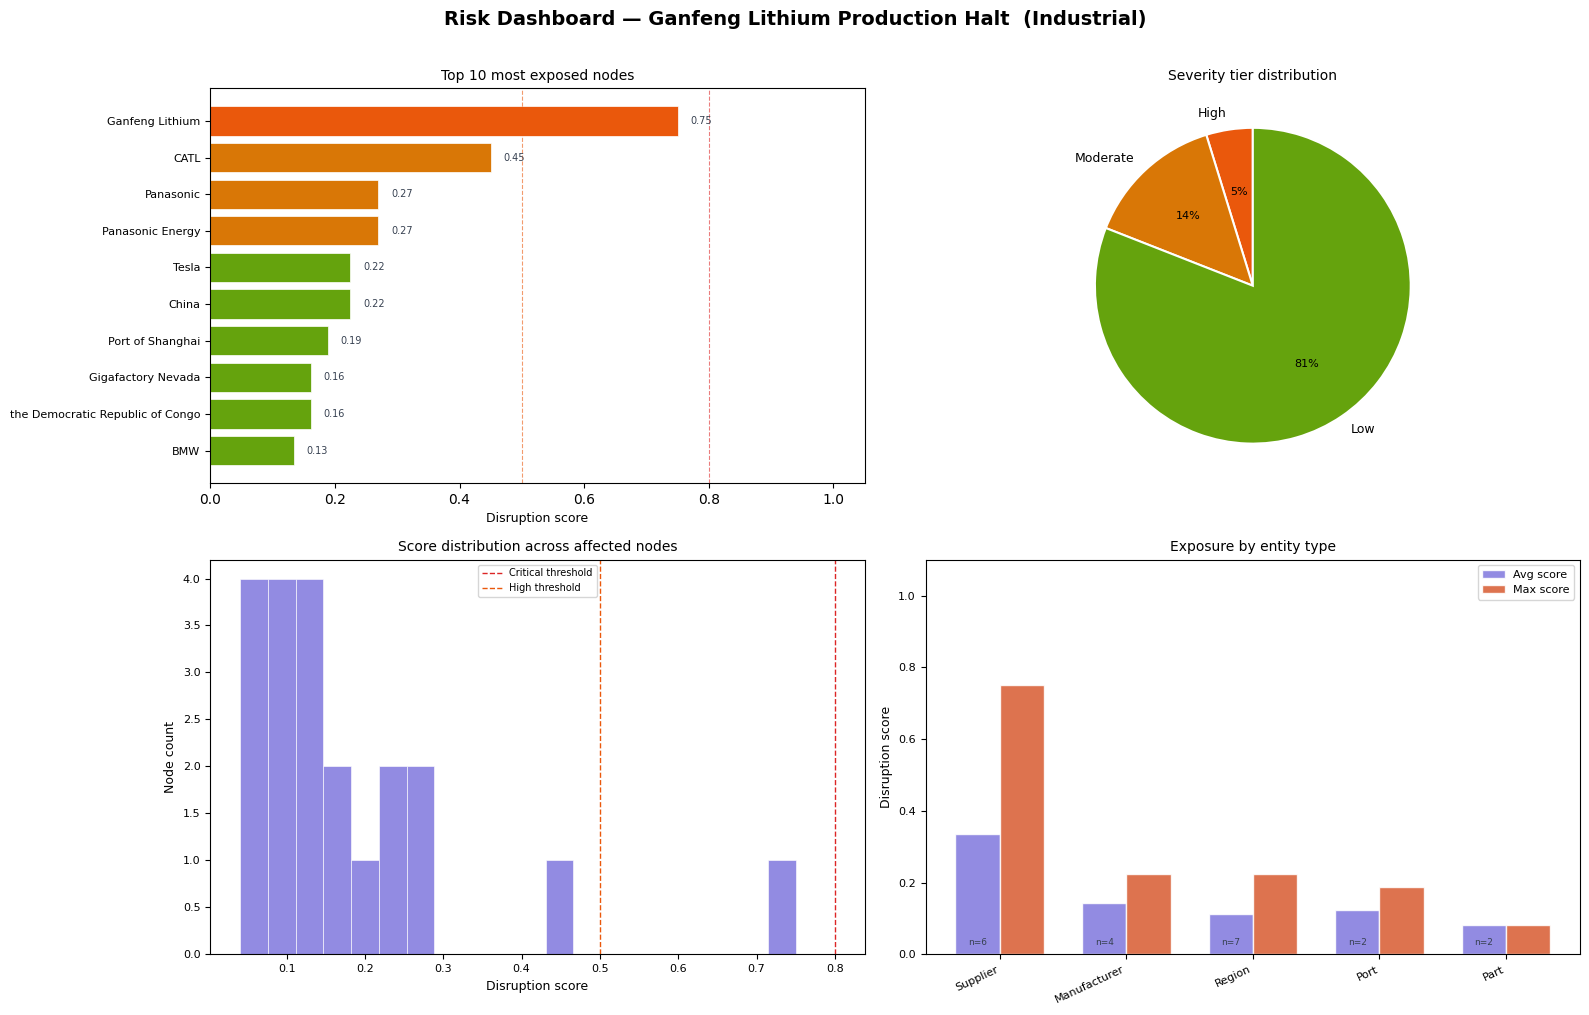

In [87]:
# ── Define a custom what-if scenario ─────────────────────────────────────────
custom_event = DisruptionEvent(
    name="Ganfeng Lithium Production Halt",
    ground_zero=["Ganfeng Lithium"],
    initial_shock=0.75,
    category=DisruptionCategory.INDUSTRIAL,
    description=(
        "A major explosion at Ganfeng Lithium's processing facility in "
        "Jiangxi reduces lithium hydroxide output by 75% for 4 months."
    ),
    metadata={"duration_weeks": 16, "output_reduction_pct": 75},
)

# Run simulation
custom_result = engine.run(
    event=custom_event,
    query="How does the Ganfeng Lithium production halt impact our EV supply chain?",
)

# Visualize
viz.disruption_map(custom_result.propagation, figsize=(16, 9))
viz.risk_dashboard(custom_result.propagation)

---

## Step 9 — Save All Outputs for Module 4

In [88]:
# ── Save simulation results ───────────────────────────────────────────────────
import pickle

# Save the Taiwan earthquake simulation result (carries everything Module 4 needs)
sim_path = DATA_PROCESSED / "simulation_taiwan.pkl"
with open(sim_path, "wb") as f:
    pickle.dump(sim_result, f)

# Save JSON summaries for all pre-built scenarios
for key, event in SCENARIO_LIBRARY.items():
    r = engine.run(event)
    r.save(DATA_PROCESSED / f"sim_{key}.json")

print("\n✓ All Module 3 outputs saved:")
for f in sorted(DATA_PROCESSED.iterdir()):
    print(f"  {f.name:45s} {f.stat().st_size:>10,} bytes")


[Engine] === Simulation: Taiwan Earthquake 2024 ===
[Engine] Step 1: Propagating disruption...
Event: Taiwan Earthquake 2024 (shock=0.85)
  Affected nodes  : 13
  Critical        : 3
  High            : 3
  Max hops reached: 4

[Engine] Step 2: GraphRAG retrieval...
[Engine] Step 3: Merging retrieval + disruption scores...
[Engine] Step 4: Building enriched prompt context...
[Engine] Result saved → ../data/processed/sim_taiwan_earthquake.json

[Engine] === Simulation: Shanghai Port Closure ===
[Engine] Step 1: Propagating disruption...
Event: Shanghai Port Closure (shock=0.90)
  Affected nodes  : 12
  Critical        : 1
  High            : 0
  Max hops reached: 5

[Engine] Step 2: GraphRAG retrieval...
[Engine] Step 3: Merging retrieval + disruption scores...
[Engine] Step 4: Building enriched prompt context...
[Engine] Result saved → ../data/processed/sim_shanghai_port_closure.json

[Engine] === Simulation: Congo Cobalt Strike ===
[Engine] Step 1: Propagating disruption...
Event: Co

---

## Module 3 — Summary

| Output | Description | Used in |
|--------|-------------|--------|
| `simulation_taiwan.pkl` | Full SimulationResult with enriched prompt | Module 4 |
| `sim_*.json` | JSON summaries for all 5 scenarios | Module 5 evaluation |
| `outputs/simulation/*.png` | Disruption maps, dashboards, trees | Report / presentation |

**What this module adds (novel contribution):**
- ✅ Supply-chain-aware disruption propagation (edge weights encode supply redundancy)
- ✅ Explainable dependency-chain traces for every exposed node
- ✅ Score merging: retrieval relevance + disruption exposure → unified LLM priority
- ✅ What-if interface: any custom event can be defined and simulated in 3 lines
- ✅ Multi-scenario comparison for evaluation

**Next:** `04_llm_generation.ipynb` — load `simulation_taiwan.pkl` and pass
`risk_report_prompt` to GPT-4o-mini or Mistral to generate the final risk report.